# <b> 01. Execution Schedules.
## <b> Adrián Vazquez </b>
---
### <b> In this first section of the project, 'Optimal Execution under Market Impact', we will build a core deterministic engine to answer:"   </b>

1. <b> How do TWAP, VWAP, and Almgren–Chriss differ in their execution schedules? </b>

2. <b> How does execution urgency λ affect the optimal inventory trajectory?  </b>

# Table of Contents

2. Deterministic Execution Strategies  
   1 TWAP  
   2 VWAP  

3. Market Impact Modeling  

4. Optimal Execution Framework (Almgren–Chriss)  

5. Almgren–Chriss Optimal Execution 

6. TWAP vs VWAP vs Almgren–Chriss :  Comparative Analysis of Execution Strategies  

7. Key Insights  and  next Steps  

8. References

In [1]:
import plotly.io as pio
pio.renderers.default = "notebook_connected+png" 

from IPython.display import Image, display
import sys
import os
# Add project root to path
sys.path.append(os.path.abspath(".."))
# libs 
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from src.models.twap import twap_schedule
from src.models.vwap import generate_vwap_schedule
from src.analytics.calculate_vwap import calculate_vwap
from src.models.almgren_chriss_shedule import almgren_chriss_schedule


## <b>  Introduction </b> 

Executing large orders in financial markets is not trivial.  
Every trade affects the price, creating a fundamental trade-off between **market impact (cost)** and **price uncertainty (risk)**.

Naive execution strategies such as **TWAP** and **VWAP** provide simple heuristics, but they do not explicitly optimize this trade-off.

This notebook develops and compares three execution approaches:

- **TWAP** — uniform execution over time  
- **VWAP** — liquidity-aligned execution  
- **Almgren–Chriss** — an optimal execution framework that balances cost and risk  

The objective is to understand how execution strategies differ structurally, how execution urgency affects optimal behavior, and to build the foundation for a quantitative evaluation under stochastic price dynamics.

In [2]:
## Base Parameters 
import numpy as np
import matplotlib.pyplot as plt

Q = 100000       # total shares
T = 1.0          # execution horizon
N = 20           # number of slices
sigma = 0.02     # volatility
gamma = 1e-6     # permanent impact
eta = 1e-5       # temporary impact
lambda_risk = 1e-6

tau = T / N
t_points = np.arange(N + 1) * tau

## <b> 1  TWAP Schedule </b>

TWAP shares per slice:
[5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000.
 5000. 5000. 5000. 5000. 5000. 5000. 5000. 5000.]

TWAP inventory path:
[100000.  95000.  90000.  85000.  80000.  75000.  70000.  65000.  60000.
  55000.  50000.  45000.  40000.  35000.  30000.  25000.  20000.  15000.
  10000.   5000.      0.]
True
True


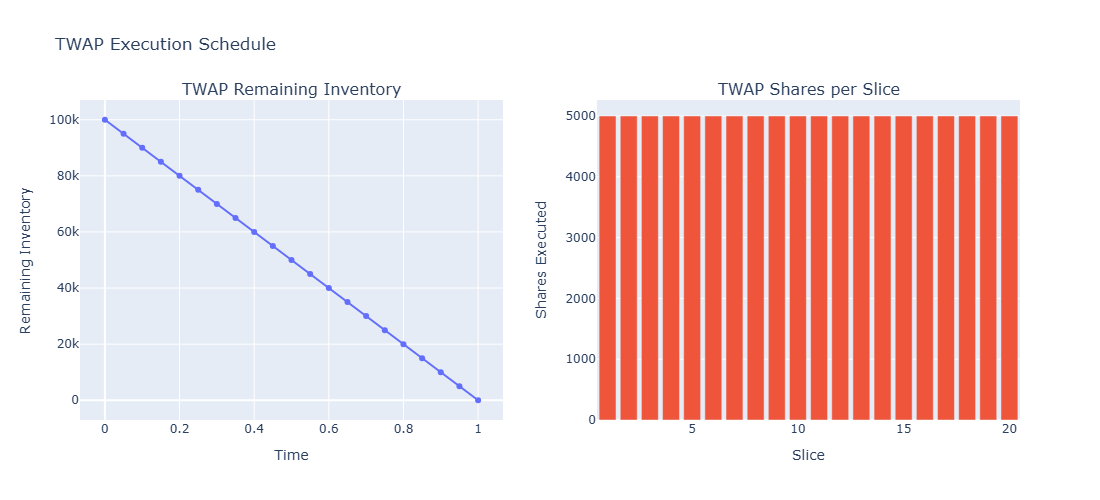

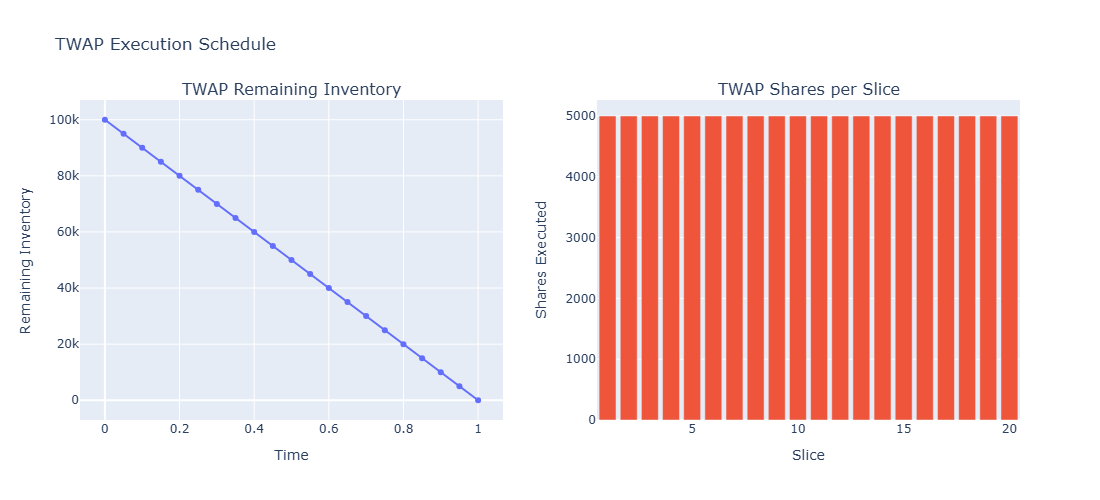

In [3]:
# Taste it 
twap_result = twap_schedule(Q, T, N)

print("TWAP shares per slice:")
print(twap_result["shares_per_slice"])

print("\nTWAP inventory path:")
print(twap_result["inventory_path"])
#  micro-check 
print(np.isclose(twap_result["inventory_path"][-1], 0))
print(np.isclose(twap_result["shares_per_slice"].sum(), Q))
# plot it 
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "TWAP Remaining Inventory",
        "TWAP Shares per Slice"
    )
)

# --- Left: Inventory Path ---
fig.add_trace(
    go.Scatter(
        x=twap_result["t_points"],
        y=twap_result["inventory_path"],
        mode="lines+markers",
        name="TWAP Inventory",
        hovertemplate="Time: %{x:.2f}<br>Inventory: %{y:,.0f}<extra></extra>"
    ),
    row=1, col=1
)

# --- Right: Shares per Slice ---
fig.add_trace(
    go.Bar(
        x=np.arange(1, N + 1),
        y=twap_result["shares_per_slice"],
        name="TWAP Shares",
        hovertemplate="Slice: %{x}<br>Shares: %{y:,.0f}<extra></extra>"
    ),
    row=1, col=2
)

# Axis labels
fig.update_xaxes(title_text="Time", row=1, col=1)
fig.update_yaxes(title_text="Remaining Inventory", row=1, col=1)

fig.update_xaxes(title_text="Slice", row=1, col=2)
fig.update_yaxes(title_text="Shares Executed", row=1, col=2)

# Layout
fig.update_layout(
    title="TWAP Execution Schedule",
    height=500,
    width=1100,
    showlegend=False
)

fig.show()
fig.write_image("../results/plots/twap_inventory.png")
display(Image(filename="../results/plots/twap_inventory.png"))

## <b> 2 VWAP Schedule </b>

### 2.1 Implementation in Execution Context

In practice, VWAP is not directly observable in advance, as future market volume is unknown. 
Instead, execution algorithms rely on an **expected volume profile**.

We approximate expected volume using a predefined distribution:

$$
w_k = \frac{V_k}{\sum_{j=1}^{N} V_j}
$$

and construct the execution schedule:

$$
n_k = Q \cdot w_k
$$

Where:
- $n_k$ = shares to execute in period $k$
- $Q$ = total order size
- $V_k$ = expected volume in period $k$
- $w_k$ = Expected volume profile

This results in a **volume-synchronized execution strategy**, where more shares are traded during periods of higher expected liquidity.

In this project, we simulate different volume profiles to analyze how VWAP-based execution compares against TWAP and optimal control strategies.

VWAP implicitly assumes that liquidity is exogenous and does not account for market impact, which may lead to suboptimal execution when order size is large relative to market volume.

### <b> 2.2 Execution Interpretation </b>

In practice, future volume is not known with certainty, so VWAP execution relies on an **expected volume curve**.

This produces a schedule that trades more aggressively in high-liquidity periods and less aggressively in low-liquidity periods.

Unlike Almgren–Chriss, VWAP does not explicitly optimize the trade-off between execution cost and risk. It is mainly a liquidity-aligned benchmark.

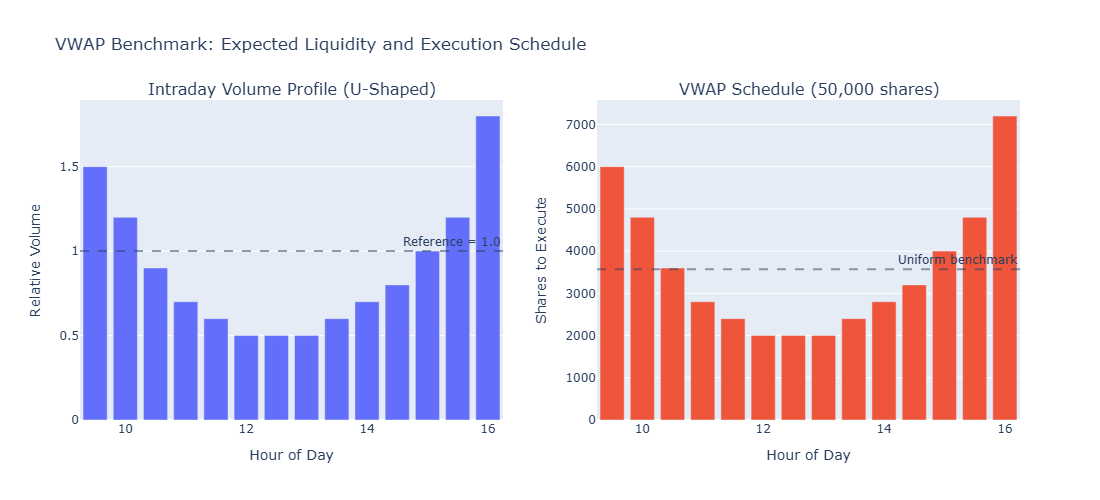

In [4]:
# Typical U-shaped intraday volume profile
# Higher volume at open and close, lower mid-day
hours = np.arange(9.5, 16.5, 0.5)  # 9:30 AM to 4:00 PM

volume_profile = np.array([
    1.5, 1.2, 0.9, 0.7, 0.6, 0.5, 0.5,
    0.5, 0.6, 0.7, 0.8, 1.0, 1.2, 1.8
], dtype=float)


total_shares = 50_000
vwap_schedule = generate_vwap_schedule(total_shares, volume_profile)
uniform_schedule = np.full_like(vwap_schedule, total_shares / len(vwap_schedule))
# Plot: Vol profile + VWAP schedule

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "Intraday Volume Profile (U-Shaped)",
        f"VWAP Schedule ({total_shares:,} shares)"
    )
)

# Left panel: volume profile
fig.add_trace(
    go.Bar(
        x=hours,
        y=volume_profile,
        name="Relative Volume",
        hovertemplate="Hour: %{x}<br>Relative Volume: %{y:.2f}<extra></extra>"
    ),
    row=1, col=1
)

fig.add_hline(
    y=1.0,
    line_dash="dash",
    opacity=0.5,
    annotation_text="Reference = 1.0",
    row=1, col=1
)

# Right panel: VWAP schedule
fig.add_trace(
    go.Bar(
        x=hours,
        y=vwap_schedule,
        name="VWAP Shares",
        hovertemplate="Hour: %{x}<br>Shares: %{y:,.0f}<extra></extra>"
    ),
    row=1, col=2
)

fig.add_hline(
    y=total_shares / len(volume_profile),
    line_dash="dash",
    opacity=0.5,
    annotation_text="Uniform benchmark",
    row=1, col=2
)

fig.update_xaxes(title_text="Hour of Day", row=1, col=1)
fig.update_yaxes(title_text="Relative Volume", row=1, col=1)

fig.update_xaxes(title_text="Hour of Day", row=1, col=2)
fig.update_yaxes(title_text="Shares to Execute", row=1, col=2)

fig.update_layout(
    height=500,
    width=1100,
    title_text="VWAP Benchmark: Expected Liquidity and Execution Schedule",
    showlegend=False
)

fig.show()
fig.write_image("../results/plots/vwap_execution.png")

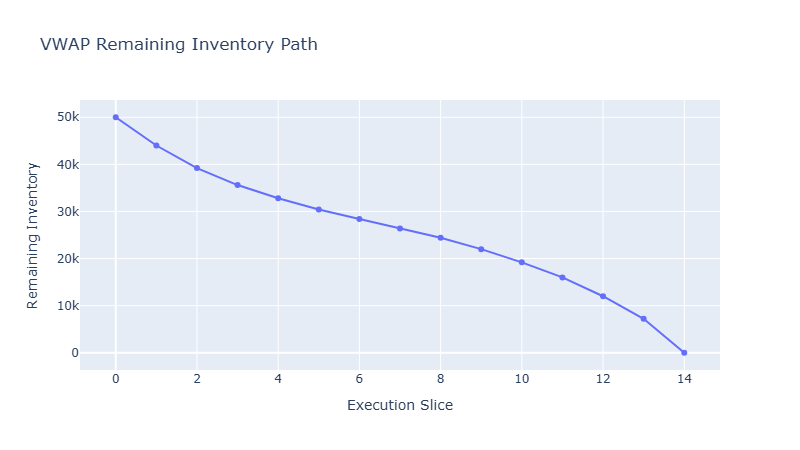

Total shares scheduled: 50,000
Largest slice allocation: 7,200 shares (14.4% of total order)
Smallest slice allocation: 2,000 shares (4.0% of total order)
Uniform benchmark per slice: 3,571.43 shares
Largest slice allocation: 7,200 shares (2.02x uniform)
Smallest slice allocation: 2,000 shares (0.56x uniform)


In [5]:
# rest inventory for  VWAP
def inventory_from_schedule(total_shares: float, shares_per_slice: np.ndarray) -> np.ndarray:
    """
    Compute remaining inventory path from an execution schedule.
    """
    shares_per_slice = np.asarray(shares_per_slice, dtype=float)
    inventory_path = total_shares - np.concatenate(([0.0], np.cumsum(shares_per_slice)))
    return inventory_path
vwap_inventory = inventory_from_schedule(total_shares, vwap_schedule)
t_points_vwap = np.arange(len(vwap_schedule) + 1)
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=t_points_vwap,
        y=vwap_inventory,
        mode="lines+markers",
        name="VWAP Inventory",
        hovertemplate="Slice: %{x}<br>Remaining Inventory: %{y:,.0f}<extra></extra>"
    )
)

fig.update_layout(
    title="VWAP Remaining Inventory Path",
    xaxis_title="Execution Slice",
    yaxis_title="Remaining Inventory",
    height=450,
    width=800
)

fig.show()
fig.write_image("../results/plots/vwap_remainig_inventory.png")

print(f"Total shares scheduled: {vwap_schedule.sum():,.0f}")
print(f"Largest slice allocation: {vwap_schedule.max():,.0f} shares ({vwap_schedule.max()/total_shares*100:.1f}% of total order)")
print(f"Smallest slice allocation: {vwap_schedule.min():,.0f} shares ({vwap_schedule.min()/total_shares*100:.1f}% of total order)")
uniform_per_slice = total_shares / len(vwap_schedule)

print(f"Uniform benchmark per slice: {uniform_per_slice:,.2f} shares")
print(f"Largest slice allocation: {vwap_schedule.max():,.0f} shares ({vwap_schedule.max()/uniform_per_slice:.2f}x uniform)")
print(f"Smallest slice allocation: {vwap_schedule.min():,.0f} shares ({vwap_schedule.min()/uniform_per_slice:.2f}x uniform)")

### <b>2.3 Interpretation</b>

The VWAP schedule concentrates execution in periods of higher expected liquidity, allocating up to **2.02×** the uniform benchmark in peak volume intervals and as low as **0.56×** in low-liquidity periods.

Unlike TWAP, which executes uniformly over time, VWAP dynamically adjusts execution intensity based on the expected market activity profile.

This makes VWAP a more realistic market-aligned benchmark, particularly in environments with uneven intraday liquidity.

However, VWAP does **not** explicitly optimize the trade-off between execution cost and risk. 
It assumes that liquidity is exogenous and does not account for market impact, which can lead to suboptimal execution when order size is large relative to market volume.

As a result, VWAP serves as a liquidity-aligned benchmark rather than an optimal execution strategy.

---

## <b> 3. Market Impact (Execution Perspective) </b>

### 3.1 <b> Why Market Impact Matters </b>

When executing large orders, trading activity affects market prices:

- Buying pushes prices upward
- Selling pushes prices downward

This creates a fundamental trade-off between:
- **Execution speed**
- **Execution cost**

Naive strategies such as TWAP and VWAP ignore this effect.

---

### <b> 3.2 Impact Decomposition </b>

We model market impact using two components:

#### Temporary Impact

$$
\Delta S_{\text{temp}}(t) = \eta \cdot v(t)
$$

- Depends on trading rate
- Represents liquidity costs (spread, urgency)
- Does not persist after execution

---

#### Permanent Impact

$$
\Delta S_{\text{perm}}(t) = \gamma \cdot (Q - x(t))
$$

- Depends on cumulative executed volume
- Represents information impact
- Persists in the price

---

### <b> 3.3 Price Model </b>

Under the linear impact model:

$$
S(t) = S_0 + \gamma (Q - x(t)) + \sigma W(t)
$$

Execution price:

$$
\tilde{S}(t) = S(t) + \eta v(t)
$$

---

### <b> 3.4 Key Insight </b>

- TWAP : ignores impact  
- VWAP : aligns with liquidity, ignores impact  
- Neither optimizes cost vs risk  

This motivates the need for an **optimal execution framework**, where trading speed is chosen to balance:

- market impact (cost)
- price uncertainty (risk)

-- This leads to the Almgren–Chriss model.

---

## <b> 4. The Almgren–Chriss Framework </b>

### <b> 4.1 Problem Formulation </b>

We seek an optimal execution trajectory $x(t)$ over $t \in [0, T]$:

- $x(t)$ = shares remaining
- $x(0) = Q$
- $x(T) = 0$

The trading rate is $v(t) = -\dot{x}(t)$.

---

### <b> 4.2 Cost–Risk Trade-off </b>

Execution involves two competing effects:

- **Temporary impact** → favors slow trading  
- **Price risk** → favors fast trading  

The Almgren–Chriss objective balances both:

$$
\min_{x(t)} \quad J[x] = \eta \int_0^T \dot{x}(t)^2 dt + \lambda \sigma^2 \int_0^T x(t)^2 dt
$$

where $\lambda$ controls execution urgency.

---

### <b> 4.3 Optimal Trajectory </b>

The optimal solution is:

$$
\boxed{x^*(t) = Q \cdot \frac{\sinh(\kappa(T-t))}{\sinh(\kappa T)}}
$$

where:

$$
\kappa = \sqrt{\frac{\lambda \sigma^2}{\eta}}
$$

---

### <b> 4.4 Interpretation </b>

- $\lambda = 0$ → TWAP (linear execution)  
- $\lambda > 0$ → front-loaded execution  
- $\lambda \to \infty$ → immediate execution  

The parameter $\kappa$ determines how aggressively the position is unwound.

This framework provides a **closed-form optimal execution strategy** under linear market impact and stochastic prices.

---

## <b> 5. Almgren–Chriss Optimal Execution </b>

### <b> Implementation </b>

We now implement the Almgren–Chriss optimal execution schedule and study how the risk-aversion parameter $\lambda$ changes the inventory trajectory and execution intensity.

The main intuition is:

- $\lambda = 0$ reproduces linear execution (TWAP)
- higher $\lambda$ leads to more front-loaded execution
- the model trades off temporary impact against timing risk

lambda=0 | kappa=0.0000 | final_inventory=0.000000 | total_scheduled=50,000
lambda=0.001 | kappa=0.0474 | final_inventory=0.000000 | total_scheduled=50,000
lambda=0.01 | kappa=0.1500 | final_inventory=0.000000 | total_scheduled=50,000
lambda=0.1 | kappa=0.4743 | final_inventory=0.000000 | total_scheduled=50,000
lambda=1 | kappa=1.5000 | final_inventory=0.000000 | total_scheduled=50,000


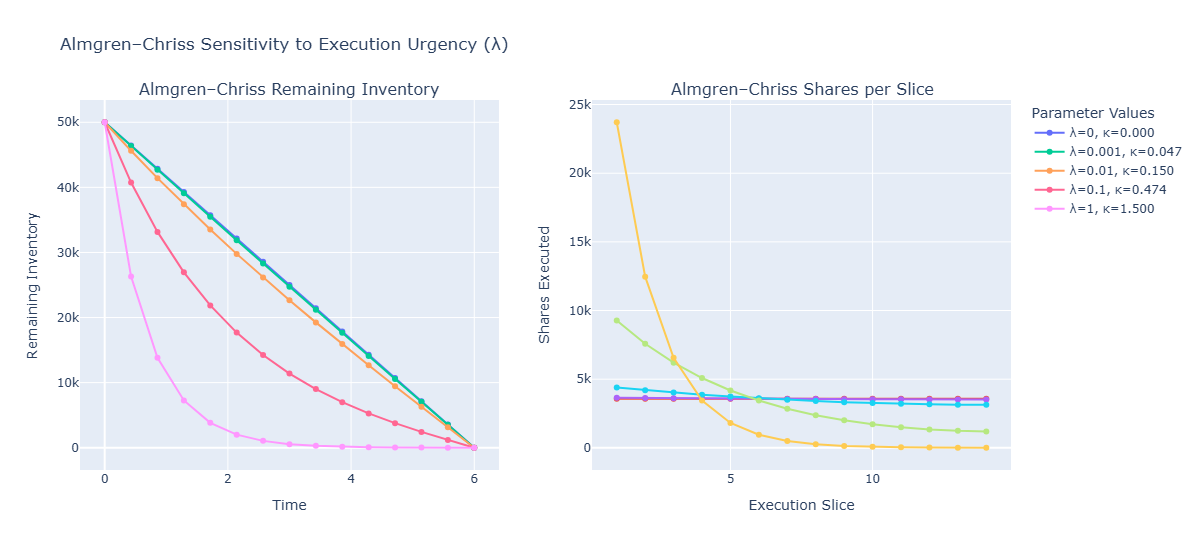

In [6]:
# Base parameters
Q = 50_000
T = 6.0
N = 14
sigma = 0.015
eta = 0.0001

lambda_values = [0.0, 1e-3, 1e-2, 1e-1, 1.0]

# Micro-check

for lam in lambda_values:
    ac_result = almgren_chriss_schedule(Q, T, N, sigma, eta, lam)
    print(
        f"lambda={lam:.3g} | "
        f"kappa={ac_result['kappa']:.4f} | "
        f"final_inventory={ac_result['inventory_path'][-1]:.6f} | "
        f"total_scheduled={ac_result['shares_per_slice'].sum():,.0f}"
    )


fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "Almgren–Chriss Remaining Inventory",
        "Almgren–Chriss Shares per Slice"
    )
)

for lam in lambda_values:
    ac_result = almgren_chriss_schedule(Q, T, N, sigma, eta, lam)

    t_points = ac_result["t_points"]
    inventory_path = ac_result["inventory_path"]
    shares_per_slice = ac_result["shares_per_slice"]
    kappa = ac_result["kappa"]

    label = f"λ={lam:.3g}, κ={kappa:.3f}"

    # Left panel: inventory path
    fig.add_trace(
        go.Scatter(
            x=t_points,
            y=inventory_path,
            mode="lines+markers",
            name=label,
            hovertemplate=(
                "Time: %{x:.2f}<br>"
                "Remaining Inventory: %{y:,.0f}<br>"
                f"{label}<extra></extra>"
            )
        ),
        row=1, col=1
    )

    # Right panel: shares per slice
    fig.add_trace(
        go.Scatter(
            x=np.arange(1, N + 1),
            y=shares_per_slice,
            mode="lines+markers",
            name=label,
            hovertemplate=(
                "Slice: %{x}<br>"
                "Shares: %{y:,.0f}<br>"
                f"{label}<extra></extra>"
            ),
            showlegend=False
        ),
        row=1, col=2
    )

fig.update_xaxes(title_text="Time", row=1, col=1)
fig.update_yaxes(title_text="Remaining Inventory", row=1, col=1)

fig.update_xaxes(title_text="Execution Slice", row=1, col=2)
fig.update_yaxes(title_text="Shares Executed", row=1, col=2)

fig.update_layout(
    title="Almgren–Chriss Sensitivity to Execution Urgency (λ)",
    height=550,
    width=1200,
    legend_title="Parameter Values"
)

fig.show()
fig.write_image("../results/plots/almgren_chriss_execution.png")

### Additional Insight

For large values of $\lambda$, the resulting execution becomes extremely aggressive, which may be unrealistic in practical settings. 

This highlights the importance of proper parameter calibration when applying the Almgren–Chriss framework in real-world scenarios.

### <b>  5.1 Interpretation </b>

The Almgren–Chriss framework dynamically adjusts execution based on the risk-aversion parameter $\lambda$.

Key observations:

- **$\lambda = 0$** produces a linear execution trajectory, equivalent to TWAP.
- As $\lambda$ increases, execution becomes increasingly **front-loaded**, with larger trades occurring early in the horizon.
- This behavior reflects a preference for reducing exposure to stochastic price risk, even at the cost of higher temporary market impact.

In the extreme case (high $\lambda$), the strategy executes a large fraction of the order immediately, minimizing timing risk but incurring significant liquidity cost.

This illustrates the fundamental trade-off:
- **Slow execution** → lower impact, higher risk  
- **Fast execution** → higher impact, lower risk  

The optimal strategy balances these effects through the parameter $\kappa$, which controls the curvature of the execution trajectory.

## <b> 6. TWAP vs VWAP vs Almgren–Chriss </b>

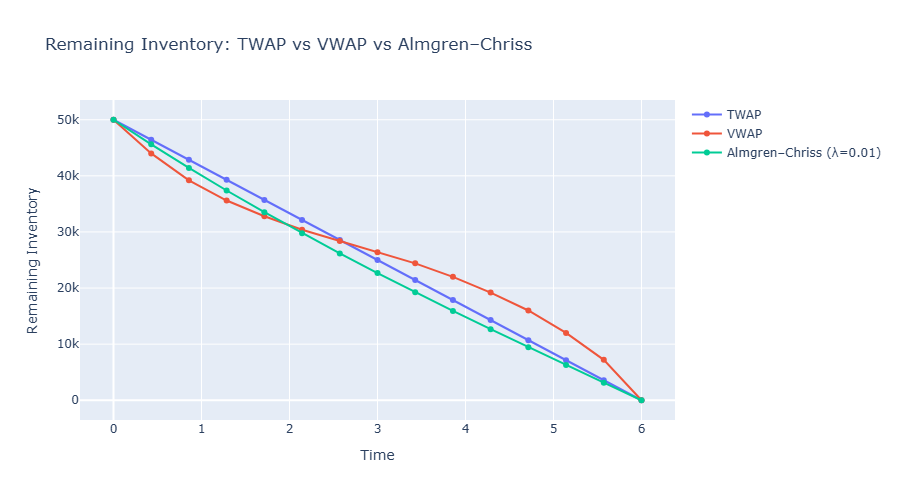

In [7]:
# Base parameters
Q = 50_000
T = 6.0
N = 14
sigma = 0.015
eta = 0.0001
lambda_risk = 1e-2

# TWAP
twap_result = twap_schedule(Q, T, N)

# VWAP
vwap_result = {
    "t_points": np.arange(N + 1) * (T / N),
    "shares_per_slice": vwap_schedule,
    "inventory_path": inventory_from_schedule(Q, vwap_schedule)
}

# Almgren-Chriss
ac_result = almgren_chriss_schedule(Q, T, N, sigma, eta, lambda_risk)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=twap_result["t_points"],
    y=twap_result["inventory_path"],
    mode="lines+markers",
    name="TWAP"
))

fig.add_trace(go.Scatter(
    x=vwap_result["t_points"],
    y=vwap_result["inventory_path"],
    mode="lines+markers",
    name="VWAP"
))

fig.add_trace(go.Scatter(
    x=ac_result["t_points"],
    y=ac_result["inventory_path"],
    mode="lines+markers",
    name=f"Almgren–Chriss (λ={lambda_risk})"
))

fig.update_layout(
    title="Remaining Inventory: TWAP vs VWAP vs Almgren–Chriss",
    xaxis_title="Time",
    yaxis_title="Remaining Inventory",
    height=500,
    width=900
)

fig.show()
fig.write_image("../results/plots/remaining_inventory_twap_vwap_alm_chriss.png")

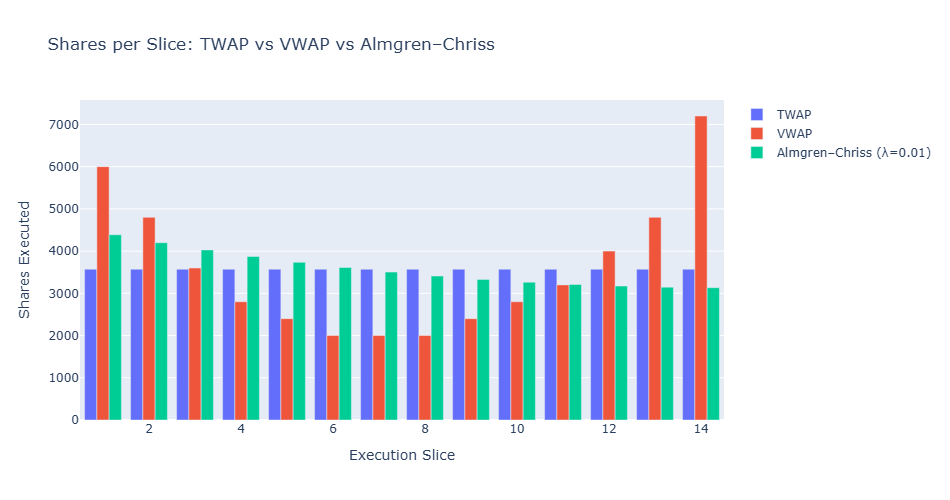

In [8]:
fig = go.Figure()

x_slices = np.arange(1, N + 1)

fig.add_trace(go.Bar(
    x=x_slices,
    y=twap_result["shares_per_slice"],
    name="TWAP"
))

fig.add_trace(go.Bar(
    x=x_slices,
    y=vwap_result["shares_per_slice"],
    name="VWAP"
))

fig.add_trace(go.Bar(
    x=x_slices,
    y=ac_result["shares_per_slice"],
    name=f"Almgren–Chriss (λ={lambda_risk})"
))

fig.update_layout(
    title="Shares per Slice: TWAP vs VWAP vs Almgren–Chriss",
    xaxis_title="Execution Slice",
    yaxis_title="Shares Executed",
    barmode="group",
    height=500,
    width=950
)

fig.show()
fig.write_image("../results/plots/shares_per_slice_twap_vwap_alm_chriss.png")


### <b> 6.1  Comparative Interpretation </b>

The three execution strategies exhibit fundamentally different behaviors:

- **TWAP** follows a linear trajectory, distributing execution uniformly over time.  
  It ignores both market liquidity conditions and execution risk.

- **VWAP** adapts execution to the expected volume profile, allocating more shares to high-liquidity periods.  
  This aligns execution with market activity but does not account for market impact or price uncertainty.

- **Almgren–Chriss** explicitly balances execution cost and timing risk.  
  With $\lambda > 0$, the strategy becomes **front-loaded**, executing more shares early to reduce exposure to stochastic price movements.

From the inventory paths, we observe that:
- Almgren–Chriss reduces inventory faster than TWAP and VWAP in early periods.
- VWAP tends to delay execution relative to TWAP when liquidity is expected later.

From the execution schedules:
- TWAP executes constant volumes.
- VWAP concentrates execution at the beginning and end (U-shaped profile).
- Almgren–Chriss smooths execution but shifts weight toward earlier slices depending on $\lambda$.

Overall, this comparison highlights that:

- **TWAP** is simple but naive  
- **VWAP** is liquidity-aware but not risk-aware  
- **Almgren–Chriss** is the only framework that optimizes the trade-off between **market impact and execution risk**

## <b> 7. Key Questions and Answers </b>
### 1. How do TWAP, VWAP, and Almgren–Chriss differ in their execution schedules?

- **TWAP** executes trades uniformly over time, ignoring both liquidity and risk considerations.
- **VWAP** aligns execution with expected market volume, concentrating trades in high-liquidity periods.
- **Almgren–Chriss** dynamically adjusts execution based on a cost–risk trade-off, leading to front-loaded or more aggressive execution depending on the value of $\lambda$.

These differences reflect increasing levels of sophistication:
from naive (TWAP) → liquidity-aware (VWAP) → optimal control (Almgren–Chriss).

### 2. How does execution urgency $\lambda$ affect the optimal inventory trajectory?

The parameter $\lambda$ controls the trade-off between execution cost and timing risk:

- **$\lambda = 0$** results in linear execution (equivalent to TWAP).
- As **$\lambda$ increases**, execution becomes more front-loaded.
- Higher values of $\lambda$ reflect greater aversion to price uncertainty, leading to faster liquidation of inventory.

This behavior is governed by the parameter $\kappa = \sqrt{\lambda \sigma^2 / \eta}$, which determines the curvature of the optimal trajectory.

---

## <b> Next Steps </b>

This notebook focused on deterministic execution strategies and their structural differences. 
The next stage of the project extends the analysis to a stochastic setting and performance evaluation.

The following components will be developed:

### 1. Stochastic Price Simulation
- Simulate price dynamics using a Brownian motion model:
  $ \
  S_{k+1} = S_k + \sigma \sqrt{\tau} \epsilon_k
  \ $
- Generate multiple price paths to evaluate execution under uncertainty

### 2. Execution with Market Impact
- Incorporate temporary and permanent impact into execution prices:
  $ \ P_k = S_k + \gamma \sum_{j<k} n_j + \eta \frac{n_k}{\tau} \ $
- Apply this framework to TWAP, VWAP, and Almgren–Chriss schedules

### 3. Performance Metrics
Evaluate execution quality using:

- **Implementation Shortfall (IS)**
- **Expected Execution Cost**
- **Execution Risk (Variance / Standard Deviation)**

---

> The next notebook will implement this stochastic execution framework and provide a quantitative comparison of execution cost and risk across strategies.

# <b> REFERENCES </b>

Almgren, R., & Chriss, N. (2000). Optimal Execution of Portfolio Transactions. Journal of Risk, 3(2), 5-39.

Almgren, R. (2003). Optimal Execution with Nonlinear Impact Functions and Trading-Enhanced Risk. Applied Mathematical Finance, 10(1), 1-18.